# MNIST Digit Clustering using t-SNE and K-Means

This project visualizes handwritten digit similarity by reducing high-dimensional image data to 2D using t-SNE and grouping them using K-Means clustering.


In [1]:
from sklearn.datasets import load_digits

# Load the dataset
digits = load_digits()

# Features and labels
X = digits.data
y = digits.target
images = digits.images

# Check dataset shape
X.shape, y.shape



((1797, 64), (1797,))

Matplotlib is building the font cache; this may take a moment.


(np.float64(-0.5), np.float64(7.5), np.float64(7.5), np.float64(-0.5))

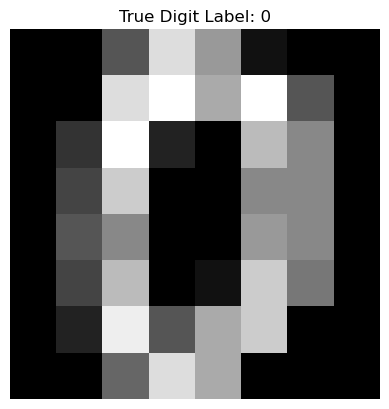

In [2]:
import matplotlib.pyplot as plt

plt.imshow(images[0], cmap="gray")
plt.title(f"True Digit Label: {y[0]}")
plt.axis("off")


In [4]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_2d = tsne.fit_transform(X)
X_2d.shape


(1797, 2)

In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(X_2d)

clusters[:10]


C:\Users\nalla\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


array([4, 6, 5, 8, 7, 1, 2, 0, 5, 1], dtype=int32)

In [6]:
!pip install plotly pandas


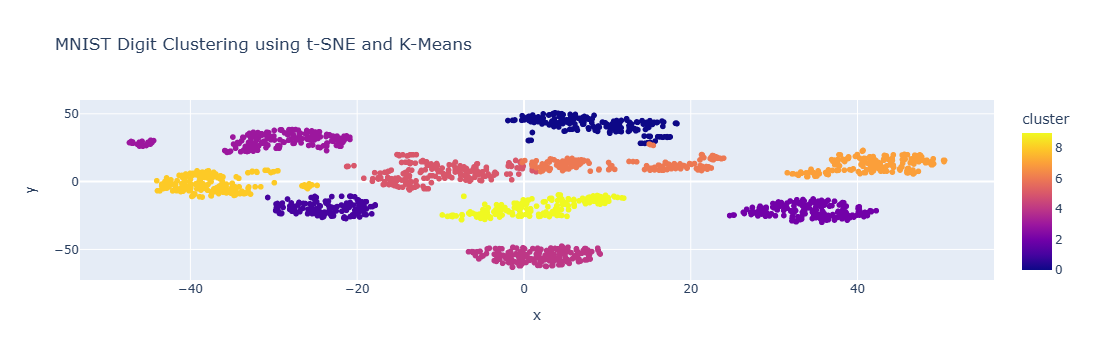

In [7]:
import pandas as pd
import plotly.express as px

df = pd.DataFrame({
    "x": X_2d[:, 0],
    "y": X_2d[:, 1],
    "cluster": clusters,
    "digit": y
})

fig = px.scatter(
    df,
    x="x",
    y="y",
    color="cluster",
    hover_data=["digit", "cluster"],
    title="MNIST Digit Clustering using t-SNE and K-Means"
)

fig.show()
